# K-Means Clustering on LEGO Dataset

Cluster LEGO sets by year and number of parts to find hidden patterns in hobbyist trends.

## 1. Setup

Import libraries and configure paths.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os

from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/AI Project'
DATA = os.path.join(BASE, 'datasets')
RESULTS = os.path.join(BASE, 'results')
os.makedirs(RESULTS, exist_ok=True)

Mounted at /content/drive


## 2. Load and Explore Data

In [2]:
sets = pd.read_csv(os.path.join(DATA, 'lego_sets.csv'))
themes = pd.read_csv(os.path.join(DATA, 'lego_themes.csv'))

themes.rename(columns={'id': 'theme_id'}, inplace=True)
df = sets.merge(themes[['theme_id', 'name']], on='theme_id', how='left')
df.rename(columns={'name_x': 'set_name', 'name_y': 'theme_name'}, inplace=True)
df = df[(df['year'] >= 1950) & (df['num_parts'] > 0)].copy()

print(f'Loaded {len(df)} LEGO sets')
df[['set_name', 'year', 'num_parts', 'theme_name']].head(10)

Loaded 19812 LEGO sets


,set_name,year,num_parts,theme_name
0,Ninjago: Book of Adventures,2022,1,Activity Books with LEGO Parts
1,Gears,1965,43,Samsonite
2,Town Mini-Figures,1979,12,Classic Town
4,Space Mini-Figures,1979,12,Supplemental
5,Space Mini-Figures,1979,12,Supplemental
6,Space Mini-Figures,1982,2,Supplemental
7,Space Mini-Figures,1979,18,Supplemental
8,Castle Mini Figures,1979,15,Classic Castle
9,4.5V Samsonite Gears Motor Set,1965,3,Samsonite
10,Master Mechanic Set,1966,403,Samsonite


## 3. Find Optimal k (Elbow + Silhouette)

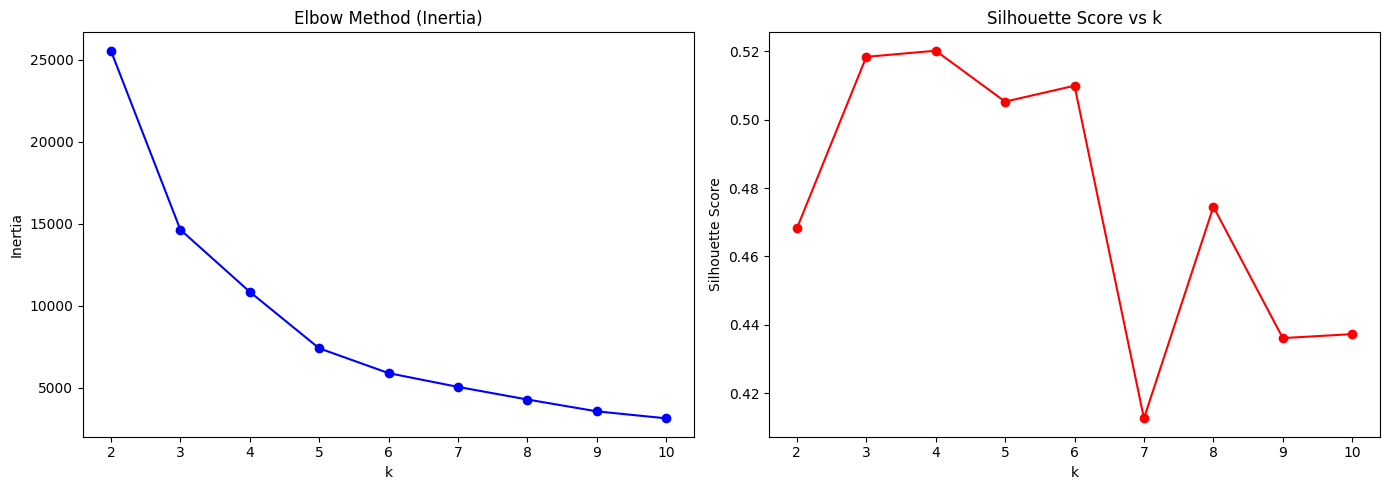

Optimal k = 4 (highest silhouette score: 0.5202)


In [3]:
X = df[['year', 'num_parts']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'lego_elbow.png'), dpi=100)
plt.show()

best_k = K_range[list(sil_scores).index(max(sil_scores))]
print(f'Optimal k = {best_k} (highest silhouette score: {max(sil_scores):.4f})')

## 4. Apply K-Means Clustering

In [4]:
k = best_k
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print(f'Silhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print(f'\nCluster Centers (scaled):')
print(pd.DataFrame(km.cluster_centers_, columns=['year', 'num_parts']))
print(f'\nCluster Sizes:')
print(df['cluster'].value_counts().sort_index())

print('\nSample sets per cluster:')
for c in sorted(df['cluster'].unique()):
    print(f'\n  Cluster {c} (n={len(df[df["cluster"]==c])}):')
    top = df[df['cluster'] == c].nsmallest(5, 'num_parts')
    for _, row in top.iterrows():
        print(f'    {row["set_name"]} ({row["year"]}, {row["num_parts"]} parts, theme: {row["theme_name"]})')

Silhouette Score: 0.5202

Cluster Centers (scaled):
       year  num_parts
0  0.505397  -0.225605
1  0.775149   6.979186
2 -1.294747  -0.273470
3  0.590008   1.582904

Cluster Sizes:
cluster
0    12104
1      201
2     5677
3     1830
Name: count, dtype: int64

Sample sets per cluster:

  Cluster 0 (n=12104):
    Ninjago: Book of Adventures (2022, 1 parts, theme: Activity Books with LEGO Parts)
    Train Connection Wire (2003, 1 parts, theme: Bulk Bricks)
    Takutanuva (2003, 1 parts, theme: Bionicle)
    Compass Sensor for Mindstorms NXT (2011, 1 parts, theme: NXT)
    Intelligent NXT Brick (Black) (2009, 1 parts, theme: NXT)

  Cluster 1 (n=201):
    The Temple Bounty (2025, 2388 parts, theme: Ninjago)
    The Burrow – Collectors' Edition (2024, 2403 parts, theme: Harry Potter)
    Shuttle Carrier Aircraft (2025, 2417 parts, theme: Icons)
    Harbormaster's Office (2025, 2419 parts, theme: BrickLink Designer Program)
    Mushroom Village (2025, 2437 parts, theme: BrickLink Designer 

## 5. Visualize Clusters

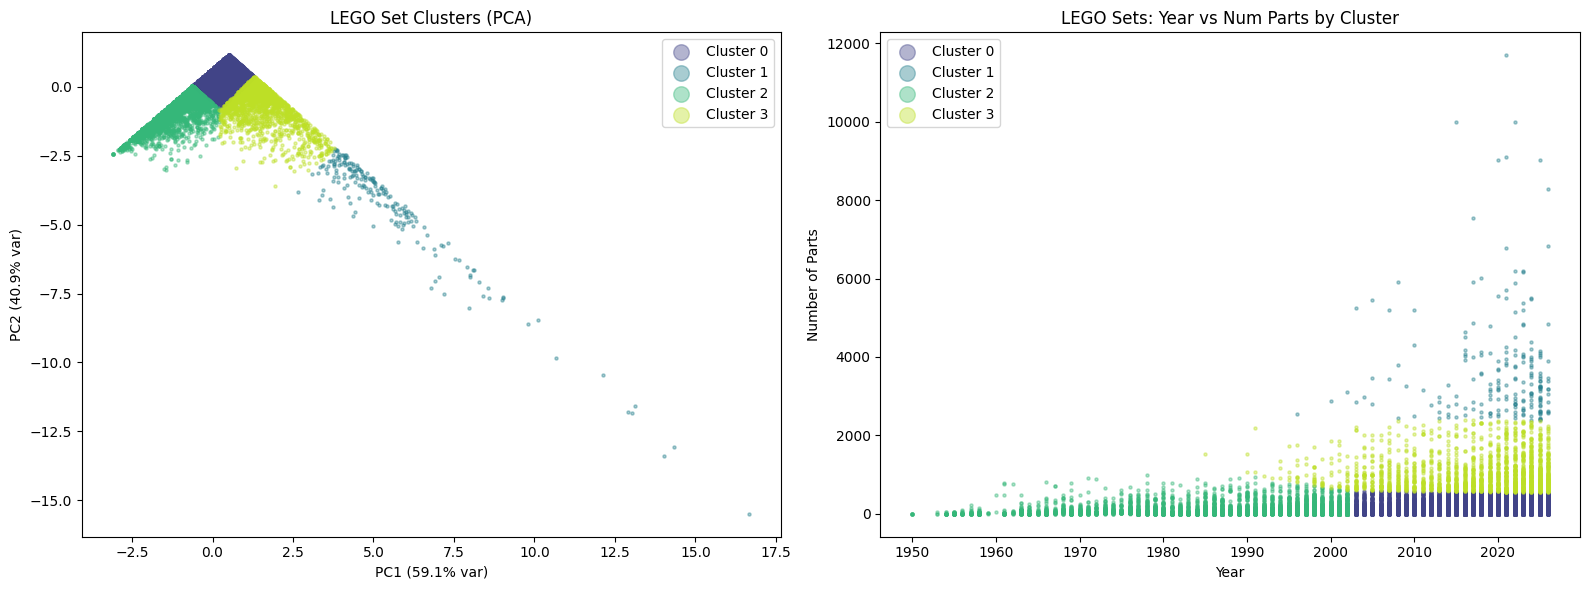

PCA explained variance: [0.59130799 0.40869201]


In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, k))
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {c}', color=colors[c], alpha=0.4, s=5)
    axes[1].scatter(df.loc[mask, 'year'], df.loc[mask, 'num_parts'],
                    label=f'Cluster {c}', color=colors[c], alpha=0.4, s=5)

axes[0].set_title('LEGO Set Clusters (PCA)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(markerscale=5)
axes[1].set_title('LEGO Sets: Year vs Num Parts by Cluster')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Number of Parts')
axes[1].legend(markerscale=5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'lego_clusters.png'), dpi=100)
plt.show()

print(f'PCA explained variance: {pca.explained_variance_ratio_}')

## 6. Summary

- **LEGO sets naturally form 4 clusters** based on year and piece count
- **Cluster 2**: Vintage sets (1950s-80s) with low part counts
- **Cluster 0**: Modern small sets (polybags, accessories)
- **Cluster 3**: Modern mid-size sets (500-1500 pieces)
- **Cluster 1**: Modern large/collector sets (2000+ pieces)